<a href="https://colab.research.google.com/github/DishaGaonkar152/Movie_Recommendation_System/blob/main/Movie_Recommendation_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas scikit-learn matplotlib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("u.data", sep="\t", names=["user_id", "movie_id", "rating", "timestamp"])
df.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
import os
os.listdir()


['.config', 'u.item', 'u.data', 'sample_data']

In [ ]:
matrix = df.pivot_table(index='user_id', columns='movie_id', values='rating').fillna(0)
print(matrix.head())

movie_id  1     2     3     4     5     6     7     8     9     10    ...  \
user_id                                                               ...   
1          5.0   3.0   4.0   3.0   3.0   5.0   4.0   1.0   5.0   3.0  ...   
2          4.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   2.0  ...   
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
5          4.0   3.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   

movie_id  1673  1674  1675  1676  1677  1678  1679  1680  1681  1682  
user_id                                                               
1          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
2          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
3          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
4          0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  
5          0.0   0.0   0.0   0.0  

In [ ]:
model = NearestNeighbors(metric='cosine', algorithm='brute')
model.fit(matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:
distances, indices = model.kneighbors([matrix.iloc[0]], n_neighbors=5)

print("Nearest Users Index:", indices)

Nearest Users Index: [[  0 915 863 267  91]]


In [ ]:
similar_users = matrix.iloc[indices[0]]
recommendations = similar_users.mean().sort_values(ascending=False)

print("Recommended Movies:")
print(recommendations.head())


Recommended Movies:
movie_id
50     5.0
174    5.0
176    4.8
172    4.8
134    4.6
dtype: float64


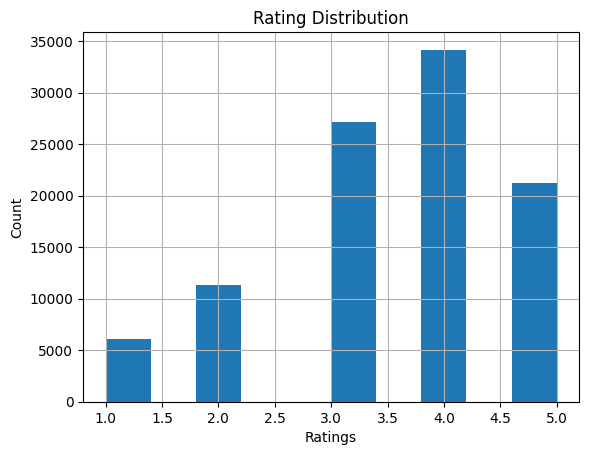

In [ ]:
df['rating'].hist()
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()

In [ ]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import ipywidgets as widgets
from IPython.display import display

In [ ]:
movies = pd.read_csv("u.item", sep="|", encoding="latin-1", header=None)

movies = movies[[0, 1]]   # Keep only movie_id and movie_name
movies.columns = ["movie_id", "title"]

print(movies.head())

   movie_id              title
0         1   Toy Story (1995)
1         2   GoldenEye (1995)
2         3  Four Rooms (1995)
3         4  Get Shorty (1995)
4         5     Copycat (1995)


In [ ]:
df = pd.read_csv("u.data", sep="\t", names=["user_id", "movie_id", "rating", "timestamp"])

movies = pd.read_csv("u.item", sep="|", encoding="latin-1", header=None)
movies = movies[[0, 1]]
movies.columns = ["movie_id", "title"]

In [ ]:
def recommend_movies(user_id):
    distances, indices = model.kneighbors([matrix.loc[user_id]], n_neighbors=5)

    similar_users = matrix.iloc[indices[0]]
    recommendations = similar_users.mean().sort_values(ascending=False).head()

    rec_df = recommendations.reset_index()
    rec_df.columns = ["movie_id", "score"]

    rec_df = rec_df.merge(movies, on="movie_id")

    print(f"\n🎬 Top Recommendations for User {user_id}:\n")
    for i, row in rec_df.iterrows():
        print(f"{i+1}. {row['title']} (Score: {round(row['score'],2)})")

In [ ]:
user_dropdown = widgets.Dropdown(
    options=matrix.index.tolist(),
    description='User ID:',
)

button = widgets.Button(description="Get Recommendations")

def on_button_click(b):
    recommend_movies(user_dropdown.value)

button.on_click(on_button_click)

display(user_dropdown, button)

Dropdown(description='User ID:', options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 2…

Button(description='Get Recommendations', style=ButtonStyle())


🎬 Top Recommendations for User 5:

1. Wrong Trousers, The (1993) (Score: 4.8)
2. Princess Bride, The (1987) (Score: 4.8)
3. Empire Strikes Back, The (1980) (Score: 4.8)
4. Monty Python and the Holy Grail (1974) (Score: 4.6)
5. Raiders of the Lost Ark (1981) (Score: 4.6)

🎬 Top Recommendations for User 9:

1. Star Wars (1977) (Score: 5.0)
2. English Patient, The (1996) (Score: 4.2)
3. Leaving Las Vegas (1995) (Score: 3.6)
4. Full Monty, The (1997) (Score: 3.0)
5. Liar Liar (1997) (Score: 2.8)


In [ ]:
# Convert recommendations index to DataFrame
recommended_movies = recommendations.head().reset_index()

# Rename column
recommended_movies.columns = ["movie_id", "score"]

# Merge with movie titles
recommended_movies = recommended_movies.merge(movies, on="movie_id")

# Display result
print("Recommended Movies with Names:\n")
print(recommended_movies[['title', 'score']])

Recommended Movies with Names:

                             title  score
0                 Star Wars (1977)    5.0
1   Raiders of the Lost Ark (1981)    5.0
2                    Aliens (1986)    4.8
3  Empire Strikes Back, The (1980)    4.8
4              Citizen Kane (1941)    4.6
